# Extremely fine extended-kagome flat-band bandwidth and bandgap

This notebook follows the structure of `fig5.ipynb` for the extremely fine extended-kagome exports. The Kagome case is $n=0$ and uses `extkag_0_extremelyfine_shb.csv`; its bandgap is defined as zero. The $n=1$ through $n=4$ cases use their complete two-band exports, with the lower band treated as dispersive and the upper band as flat.

In [4]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

notebook_dir = Path.cwd()
if not (notebook_dir / 'defs.py').is_file():
    notebook_dir = Path('processing/notebooks/paper_fig_upload')
sys.path.insert(0, str(notebook_dir.resolve()))

# Refresh the helper module in a reused Jupyter kernel.
sys.modules.pop('defs', None)

from defs import band_frequency_matrix, extract_band_structure

In [5]:
data_dir = next(
    path.resolve()
    for path in (Path('../../../data/simulation'), Path('data/simulation'))
    if path.is_dir()
)
out_dir = next(
    path.resolve()
    for path in (Path('../../../output/paper_upload'), Path('output/paper_upload'))
    if path.is_dir()
)

# Plot output toggles
SHOW_AXIS_TICKS_AND_LABELS = False
SAVE_PLOT = True
EXPECTED_INTERCELL_SITES = (0, 1, 2, 3)
EXTENDED_KAGOME_INTERCELL_SITES = (1, 2, 3)


## Discover the extremely fine exports

In [ ]:
kagome_file = data_dir / 'extkag_0_fluid_custom_mesh_allbands.csv'
if not kagome_file.is_file():
    raise FileNotFoundError(f'Kagome source file not found: {kagome_file}')

filename_pattern = re.compile(
    r'^extkag_(\d+)_fluid_custom_mesh_2bands\.csv$'
)
band_files = {}
for csv_path in data_dir.glob('extkag_*_fluid_custom_mesh_2bands.csv'):
    match = filename_pattern.match(csv_path.name)
    if match is None:
        continue
    intercell_sites = int(match.group(1))
    if intercell_sites not in EXTENDED_KAGOME_INTERCELL_SITES:
        continue
    if intercell_sites in band_files:
        raise ValueError(f'Multiple two-band files found for n={intercell_sites}')
    band_files[intercell_sites] = csv_path

band_files = dict(sorted(band_files.items()))
if set(band_files) != set(EXTENDED_KAGOME_INTERCELL_SITES):
    missing = set(EXTENDED_KAGOME_INTERCELL_SITES) - set(band_files)
    raise FileNotFoundError(
        'Missing fluid coarse two-band exports for n='
        + ', '.join(map(str, sorted(missing)))
    )

print(f'n=0 (Kagome): {kagome_file.name}')
for intercell_sites, csv_path in band_files.items():
    print(f'  n={intercell_sites}: {csv_path.name}')
file_labels = {
    re.sub(r'^extkag_\d+_', '', csv_path.stem)
    for csv_path in band_files.values()
}
if len(file_labels) > 1:
    raise ValueError(
        f'Expected one file label across inputs, found {sorted(file_labels)}'
    )
file_label = next(iter(file_labels), '')


n=0 (Kagome): extkag_0_fluid_custom_mesh_allbands.csv
  n=1: extkag_1_fluid_custom_mesh_2bands.csv
  n=2: extkag_2_fluid_custom_mesh_2bands.csv
  n=3: extkag_3_fluid_custom_mesh_2bands.csv


## Extract and organize the two highest bands

In [7]:
band_data = {
    0: extract_band_structure(
        kagome_file, max_bands=3, band_selection='top'
    ),
    **{
        intercell_sites: extract_band_structure(
            csv_path, max_bands=2, band_selection='top'
        )
        for intercell_sites, csv_path in band_files.items()
    },
}

for intercell_sites, dataset in band_data.items():
    b_count, band_count = band_frequency_matrix(dataset).shape
    expected_band_count = 3 if intercell_sites == 0 else 2
    if band_count != expected_band_count:
        raise ValueError(
            f'n={intercell_sites} contains {band_count} bands, '
            f'expected {expected_band_count}'
        )
    print(
        f'n={intercell_sites}: selected the {band_count} bands '
        f'at {b_count} b values'
    )

n=0: selected the 3 bands at 48 b values
n=1: selected the 2 bands at 48 b values
n=2: selected the 2 bands at 48 b values
n=3: selected the 2 bands at 48 b values


## Calculate the flat-band bandwidth and bandgap

The highest extracted band is treated as the flat band. For $n=1$ through $n=4$, the lower band is the dispersive band and the bandgap is $\min(f_\mathrm{flat})-\max(f_\mathrm{disp})$, clipped at zero. For Kagome ($n=0$), the flat-band bandwidth is extracted from the highest of the three selected bands and the bandgap is set to zero.

In [8]:
def calculate_flat_band_metrics(dataset, *, bandgap_override_hz=None):
    bands_hz = band_frequency_matrix(dataset)
    flat_band_hz = bands_hz[:, -1]
    if bands_hz.shape[1] < 2:
        raise ValueError('At least one dispersive band is required')
    highest_dispersive_hz = bands_hz[:, :-1].max()
    if bandgap_override_hz is None:
        signed_bandgap_hz = flat_band_hz.min() - highest_dispersive_hz
        bandgap_hz = max(0.0, signed_bandgap_hz)
    else:
        bandgap_hz = float(bandgap_override_hz)

    return {
        'minimum_hz': flat_band_hz.min(),
        'maximum_hz': flat_band_hz.max(),
        'bandwidth_hz': np.ptp(flat_band_hz),
        'highest_dispersive_hz': highest_dispersive_hz,
        'bandgap_hz': bandgap_hz,
    }

In [9]:
flat_band_metrics = {
    0: calculate_flat_band_metrics(band_data[0], bandgap_override_hz=0.0),
    **{
        intercell_sites: calculate_flat_band_metrics(dataset)
        for intercell_sites, dataset in band_data.items()
        if intercell_sites != 0
    },
}

for intercell_sites in EXPECTED_INTERCELL_SITES:
    metrics = flat_band_metrics[intercell_sites]
    label = 'Kagome' if intercell_sites == 0 else f'n={intercell_sites}'
    print(
        f'{label}: '
        f'bandwidth={metrics["bandwidth_hz"]:.6g} Hz, '
        f'bandgap={metrics["bandgap_hz"]:.6g} Hz'
    )

Kagome: bandwidth=305.383 Hz, bandgap=0 Hz
n=1: bandwidth=0.111903 Hz, bandgap=171.74 Hz
n=2: bandwidth=0.00432228 Hz, bandgap=584.105 Hz
n=3: bandwidth=0.000249845 Hz, bandgap=703.817 Hz


### Flat-band results table

In [10]:
results_table_lines = [
    '| Intercell sites | Flat-band frequency range (kHz) | Flat-band width (Hz) | Bandgap (Hz) |',
    '|--:|--:|--:|--:|',
]

for intercell_sites in EXPECTED_INTERCELL_SITES:
    metrics = flat_band_metrics[intercell_sites]
    label = f'{intercell_sites} (Kagome)' if intercell_sites == 0 else str(intercell_sites)

    frequency_range_khz = (
        f'{metrics["minimum_hz"] / 1e3:.6f}–'
        f'{metrics["maximum_hz"] / 1e3:.6f}'
    )
    results_table_lines.append(
        f'| {label} | {frequency_range_khz} | '
        f'{metrics["bandwidth_hz"]:.6g} | '
        f'{metrics["bandgap_hz"]:.6g} |'
    )

results_table_markdown = '\n'.join(results_table_lines)
display(Markdown(results_table_markdown))

| Intercell sites | Flat-band frequency range (kHz) | Flat-band width (Hz) | Bandgap (Hz) |
|--:|--:|--:|--:|
| 0 (Kagome) | 14.307420–14.612803 | 305.383 | 0 |
| 1 | 14.412826–14.412938 | 0.111903 | 171.74 |
| 2 | 14.418408–14.418413 | 0.00432228 | 584.105 |
| 3 | 14.412085–14.412085 | 0.000249845 | 703.817 |

In [11]:
intercell_site_counts = np.asarray(EXPECTED_INTERCELL_SITES)
bandgaps_hz = np.asarray([
    flat_band_metrics[n]['bandgap_hz']
    for n in intercell_site_counts
])
bandwidths_hz = np.asarray([
    flat_band_metrics[n]['bandwidth_hz']
    for n in intercell_site_counts
])

## Plot the results

In [12]:
def plot_metric(values, *, yscale='linear', yticks=None):
    fig, ax = plt.subplots(figsize=(2, 1.5), tight_layout=True)
    ax.plot(
        intercell_site_counts, values,
        color='black', linestyle=':', linewidth=0.5,
    )
    ax.plot(
        intercell_site_counts, values,
        color='blue', linestyle='none', marker='.', markersize=5,
    )
    ax.set_yscale(yscale)
    ax.set_xticks(intercell_site_counts)
    if yticks is not None:
        ax.set_yticks(yticks)

    ax.tick_params(
        axis='both', width=0.25, length=1,
    )
    for spine in ax.spines.values():
        spine.set_linewidth(0.25)

    if not SHOW_AXIS_TICKS_AND_LABELS:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title('')
        ax.tick_params(axis='x', labelbottom=False)
        ax.tick_params(axis='y', labelleft=False)
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    return fig, ax

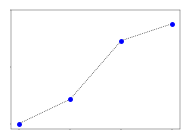

In [13]:
if intercell_site_counts.size:
    fig, ax = plot_metric(
        bandgaps_hz, yticks=np.linspace(0, 800, 3)
    )
    plt.show()
    if SAVE_PLOT:
        out_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            out_dir / f'extkag_bandgap_{file_label}.pdf',
            bbox_inches='tight',
        )
else:
    print('No bandgap data to plot yet')

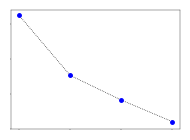

In [14]:
if intercell_site_counts.size:
    fig, ax = plot_metric(
        bandwidths_hz,
        yscale='log',
        yticks=10 ** np.linspace(-4, 2, 4),
    )
    # ax.set_xlabel('Number of intercell sites', fontsize=7)
    # ax.set_ylabel('Flatband width (Hz)', fontsize=7)
    plt.show()
    
    if SAVE_PLOT:
        out_dir.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            out_dir / f'extkag_bandwidth_{file_label}.pdf',
            bbox_inches='tight',
        )
else:
    print('No bandwidth data to plot yet')

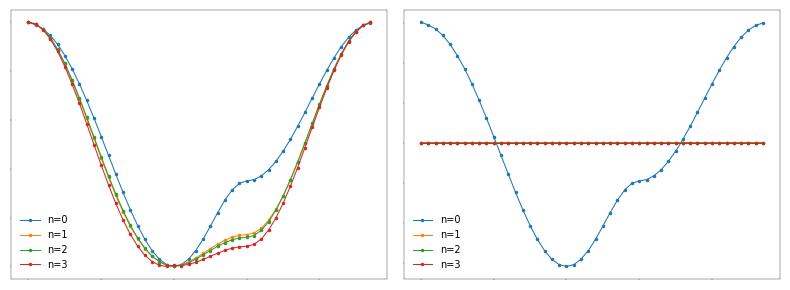

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3), tight_layout=True)

for intercell_sites, dataset in band_data.items():
    b_values = np.asarray(list(dataset['frequencies_by_b_hz']))
    flat_band_hz = band_frequency_matrix(dataset)[:, -1]
    minimum_hz = flat_band_hz.min()
    maximum_hz = flat_band_hz.max()
    bandwidth_hz = maximum_hz - minimum_hz
    normalized_flat_band = (
        (flat_band_hz - minimum_hz) / bandwidth_hz
        if bandwidth_hz > 0
        else np.zeros_like(flat_band_hz)
    )
    label = f'n={intercell_sites}'
    axes[0].plot(b_values, normalized_flat_band, marker='.', linewidth=0.75, markersize=3, label=label)
    axes[1].plot(b_values, (flat_band_hz-np.average(flat_band_hz)) / 1e3, marker='.', linewidth=0.75, markersize=3, label=label)

axes[0].set_xlabel('b')
axes[0].set_ylabel('Normalized flat-band frequency')
axes[1].set_xlabel('b')
axes[1].set_ylabel('Frequency (kHz)')
axes[0].set_ylim(-0.05, 1.05)
for ax in axes:
    ax.legend(frameon=False, fontsize=7)
    ax.tick_params(axis='both', width=0.25, length=1)
    for spine in ax.spines.values():
        spine.set_linewidth(0.25)
    if not SHOW_AXIS_TICKS_AND_LABELS:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelbottom=False)
        ax.tick_params(axis='y', labelleft=False)

plt.show()
if SAVE_PLOT:
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        out_dir / f'extkag_flat_band_shape_{file_label}.pdf',
        bbox_inches='tight',
    )